# Notebook 2 — Correções: Granularidade, Balanceamento e Pipeline

Continuação do Notebook 1 (pipeline ruim). Aqui aplicamos:
- **Task bundling** (várias imagens por tarefa)
- **Particionamento cíclico**
- **Agendamento mais dinâmico**
- **Redução de overhead e I/O**
- **Comparação antes/depois**

> Regra: toda melhoria deve ser validada com medição.


In [1]:

from __future__ import annotations
import os, time, random, shutil
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import cv2
from concurrent.futures import ProcessPoolExecutor, as_completed

try:
    from IPython.display import display
except Exception:
    display = print

RNG = np.random.default_rng(42)
random.seed(42)
plt.rcParams["figure.figsize"]=(8,4); plt.rcParams["axes.grid"]=True


## 1. Diretórios


In [2]:

DIGITAIS_DIR = Path("/mnt/c/Users/chaul.NK/Dropbox/_FATESG/CP/data/digitais")
FACES_DIR = Path("/mnt/c/Users/chaul.NK/Dropbox/_FATESG/CP/data/faces")

OUTPUT_ROOT = Path("./saida_notebook2_otimizado")
DIGITAIS_OUT_DIR = OUTPUT_ROOT / "digitais_processadas_ok"

IMAGE_EXTS = {".png",".jpg",".jpeg",".bmp",".tif",".tiff"}
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
DIGITAIS_OUT_DIR.mkdir(parents=True, exist_ok=True)

print("DIGITAIS_DIR:", DIGITAIS_DIR.exists(), DIGITAIS_DIR)
print("FACES_DIR:", FACES_DIR.exists(), FACES_DIR)


DIGITAIS_DIR: True /mnt/c/Users/chaul.NK/Dropbox/_FATESG/CP/data/digitais
FACES_DIR: True /mnt/c/Users/chaul.NK/Dropbox/_FATESG/CP/data/faces


## 2. Utilitários


In [3]:

def list_image_files(folder: Path, limit=None):
    files=[p for p in folder.rglob("*") if p.suffix.lower() in IMAGE_EXTS]
    files=sorted(files)
    return files[:limit] if limit else files

def load_gray(p: Path):
    img=cv2.imread(str(p), cv2.IMREAD_GRAYSCALE)
    if img is None: raise ValueError(f"Falha ao ler {p}")
    return img

def chunk(seq, size):
    for i in range(0,len(seq),size):
        yield seq[i:i+size]

def partition_cyclic(items, n):
    parts=[[] for _ in range(n)]
    for i,x in enumerate(items): parts[i % n].append(x)
    return parts


## 3. Dados


In [4]:

MAX_DIGITAIS=100; MAX_FACES=100
digitais=list_image_files(DIGITAIS_DIR, MAX_DIGITAIS)
faces=list_image_files(FACES_DIR, MAX_FACES)

tasks = ([{"kind":"fingerprint","path":p} for p in digitais] +
         [{"kind":"face","path":p} for p in faces])

print("Total:", len(tasks))
if not tasks:
    raise RuntimeError("Sem dados. Verifique paths.")

df=pd.DataFrame({"kind":[t["kind"] for t in tasks]})
display(df["kind"].value_counts())


Total: 200


kind
fingerprint    100
face           100
Name: count, dtype: int64

## 4. Pipelines (otimizados levemente)


In [5]:

def fingerprint_pipeline_ok(path: Path, save_dir: Path, save=False):
    t0=time.perf_counter()
    img=load_gray(path)

    # Fusão de etapas (reduz cópias)
    clahe=cv2.createCLAHE(clipLimit=2.5, tileGridSize=(8,8))
    x=clahe.apply(img)
    x=cv2.equalizeHist(x)
    x=cv2.GaussianBlur(x,(5,5),1.2)

    if save:
        out=save_dir / f"{path.stem}_ok.png"
        cv2.imwrite(str(out), x)

    return {
        "kind":"fingerprint","pid":os.getpid(),
        "task_time_s": time.perf_counter()-t0
    }

def face_pipeline_ok(path: Path):
    t0=time.perf_counter()
    img=load_gray(path).astype(np.float32)/255.0
    img=cv2.resize(img,(128,128))

    # Menos iterações + vetorizado
    for _ in range(3):
        f=np.fft.fft2(img)
        img=np.real(np.fft.ifft2(f))

    hist,_=np.histogram(img.ravel(), bins=32, range=(0,1))
    hist=hist.astype(float); hist/=hist.sum()+1e-8

    return {
        "kind":"face","pid":os.getpid(),
        "task_time_s": time.perf_counter()-t0
    }

def process_bundle(bundle, save_dir, save=False):
    out=[]
    for t in bundle:
        if t["kind"]=="fingerprint":
            out.append(fingerprint_pipeline_ok(t["path"], save_dir, save))
        else:
            out.append(face_pipeline_ok(t["path"]))
    return out


## 5. Baselines


In [15]:

def run_seq(tasks):
    t0=time.perf_counter()
    res=[]
    for t in tasks:
        if t["kind"]=="fingerprint":
            res.append(fingerprint_pipeline_ok(t["path"], DIGITAIS_OUT_DIR, save=False))
        else:
            res.append(face_pipeline_ok(t["path"]))
    return res, time.perf_counter()-t0

def run_parallel_bad(tasks, workers=4):
    # 1 tarefa por item (ainda ruim)
    t0=time.perf_counter()
    res=[]
    with ProcessPoolExecutor(max_workers=workers) as ex:
        futs=[ex.submit(process_bundle,[t], DIGITAIS_OUT_DIR, False) for t in tasks]
        for f in as_completed(futs):
            res.extend(f.result())
    return res, time.perf_counter()-t0

def run_parallel_bundle(tasks, bundle_size=8, workers=4):
    t0=time.perf_counter()
    res=[]
    bundles=list(chunk(tasks, bundle_size))
    with ProcessPoolExecutor(max_workers=workers) as ex:
        futs=[ex.submit(process_bundle,b, DIGITAIS_OUT_DIR, False) for b in bundles]
        for f in as_completed(futs):
            res.extend(f.result())
    return res, time.perf_counter()-t0

def run_parallel_cyclic(tasks, bundle_size=8, workers=4):
    parts=partition_cyclic(tasks, workers)
    t0=time.perf_counter()
    res=[]
    with ProcessPoolExecutor(max_workers=workers) as ex:
        futs=[ex.submit(process_bundle, part, DIGITAIS_OUT_DIR, False) for part in parts]
        for f in as_completed(futs):
            res.extend(f.result())
    return res, time.perf_counter()-t0

P=min(4, os.cpu_count() or 4)

BUNDLE_SIZE = 12
P = 4

seq_r, seq_t = run_seq(tasks)
bad_r, bad_t = run_parallel_bad(tasks, P)
bun_r, bun_t = run_parallel_bundle(tasks, BUNDLE_SIZE, P)
cyc_r, cyc_t = run_parallel_cyclic(tasks, BUNDLE_SIZE, P)

df=pd.DataFrame({
    "modo":["seq","par_ruim","bundle","ciclico"],
    "tempo":[seq_t, bad_t, bun_t, cyc_t]
})
df["speedup"]=seq_t/df["tempo"]
df["eficiencia"]=df["speedup"]/P
display(df.sort_values("tempo"))


,modo,tempo,speedup,eficiencia
3,ciclico,0.517553,4.772929,1.193232
2,bundle,0.617034,4.003413,1.000853
1,par_ruim,0.654414,3.774741,0.943685
0,seq,2.470244,1.000000,0.250000


## 6. Carga por worker


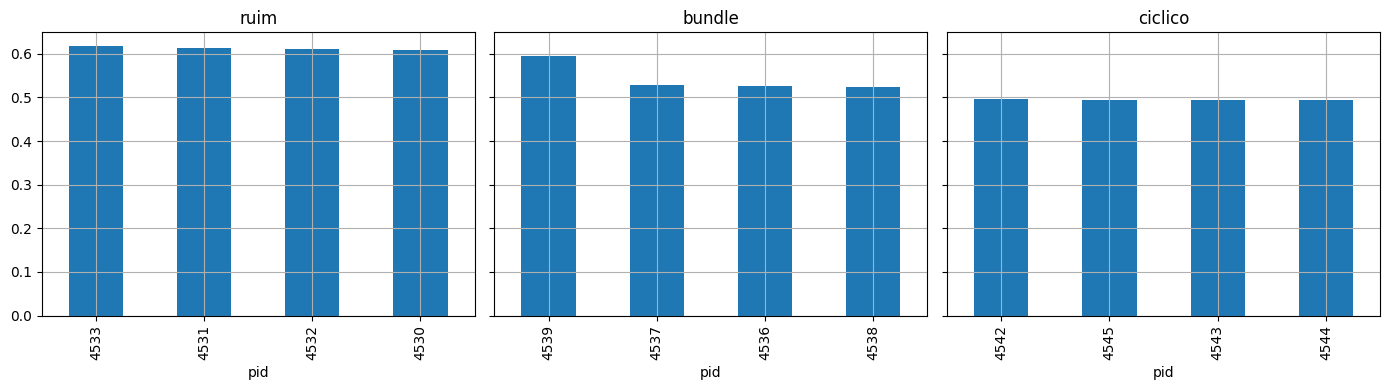

In [16]:

def load_by_worker(res):
    d=pd.DataFrame(res)
    return d.groupby("pid")["task_time_s"].sum().reset_index().sort_values("task_time_s", ascending=False)

fig,ax=plt.subplots(1,3,figsize=(14,4),sharey=True)
for data, title, axi in [
    (bad_r,"ruim",ax[0]),
    (bun_r,"bundle",ax[1]),
    (cyc_r,"ciclico",ax[2]),
]:
    l=load_by_worker(data)
    l.plot.bar(x="pid", y="task_time_s", ax=axi, legend=False, title=title)
plt.tight_layout(); plt.show()


## 7. Conclusões esperadas

- bundling ↓ overhead
- cíclico ↑ balanceamento
- fusão de etapas ↓ custo
- menos I/O ↑ throughput

> Melhor desempenho vem da combinação: granularidade + balanceamento + otimização local.


## 8. Desafios

- variar `bundle_size`
- variar número de workers
- habilitar salvamento de fingerprints e medir impacto
- misturar ordem vs ordenado por custo


In [8]:
pass
